In [6]:
# Step 1: Clean uninstall
!pip uninstall -y torch torchvision torchaudio

# Step 2: Install compatible CPU version (IMPORTANT)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# Step 3: Install your chatbot library
!pip install sentence-transformers

Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.11.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.26.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached https://download-r2.pytorch.org/whl/cpu/torchaudio-2.11.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
Using cached https://download-r2.pytorch.org/whl/cpu/torch-2.11.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl (190.3 MB)
Using cached https://download-r2.pytorch.org/whl/cpu/torchvision-0.26.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl (1.9 MB)
Using cached https://download-r2.pytorch.org/whl/cpu/torchaudio-2.11.0%2Bcpu-cp312-cp312-manylinux_2_28_x86_64.whl (341 kB)


In [1]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cpu
False


In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
import numpy as np
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully


In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import pandas as pd
import numpy as np
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
df = pd.read_csv("university_queries_test_1k.csv")

question_col = df.columns[0]
answer_col = df.columns[1]

df[question_col] = df[question_col].astype(str)
df[answer_col] = df[answer_col].astype(str)

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

df[question_col] = df[question_col].apply(clean_text)

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
question_embeddings = model.encode(df[question_col].tolist())

In [ ]:
def rule_based_response(user_input):
    text = user_input.lower()

    if "admission" in text or "eligibility" in text:
        return "Admission requires 10th & 12th pass with minimum 50% marks."

    if "fees" in text:
        return "Fees can be paid online or at the accounts office."

    if "hostel" in text:
        return "Hostel facilities include WiFi, security, and mess."

    if "attendance" in text:
        return "Minimum 75% attendance is required."

    if "scholarship" in text:
        return "Scholarships are available based on merit and category."

    return None

In [ ]:
def retrieval_response(user_input):
    user_clean = clean_text(user_input)
    user_embedding = model.encode([user_clean])

    similarity = cosine_similarity(user_embedding, question_embeddings)
    idx = np.argmax(similarity)

    # Confidence check
    if similarity[0][idx] < 0.4:
        return "Sorry, I didn't understand your question clearly."

    return df.iloc[idx][answer_col]

In [ ]:
def chatbot(user_input):
    rule = rule_based_response(user_input)

    if rule:
        return rule

    return retrieval_response(user_input)

In [12]:
print("Chatbot is ready! Type 'exit' to stop.\n")

while True:
    user_input = input("You: ")

    if user_input.lower() == "exit":
        print("Chatbot: Goodbye!")
        break

    response = chatbot(user_input)
    print("Chatbot:", response)

Chatbot is ready! Type 'exit' to stop.



KeyboardInterrupt: Interrupted by user

In [ ]:
# =========================
# Evaluation Section
# =========================

correct = 0
total = 100   # number of test samples

for i in range(total):
    question = df.iloc[i][question_col]
    actual_answer = df.iloc[i][answer_col]

    predicted_answer = retrieval_response(question)

    if predicted_answer == actual_answer:
        correct += 1

accuracy = correct / total

print("Model Accuracy:", accuracy)

Model Accuracy: 0.93


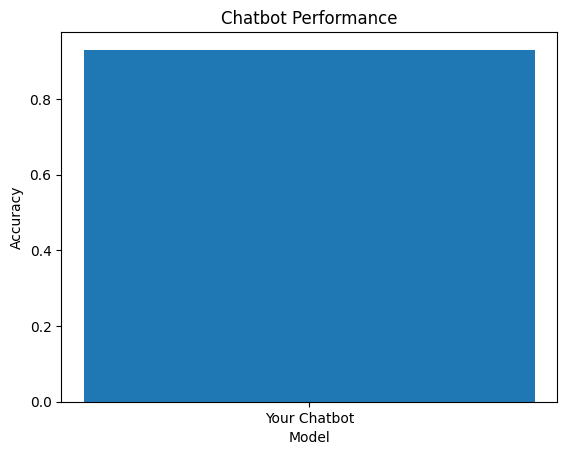

In [ ]:
import matplotlib.pyplot as plt

methods = ["Your Chatbot"]
accuracies = [accuracy]

plt.figure()
plt.bar(methods, accuracies)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Chatbot Performance")

plt.show()

In [ ]:
scores = []

for i in range(50):
    question = df.iloc[i][question_col]

    user_embedding = model.encode([question])
    similarity = cosine_similarity(user_embedding, question_embeddings)

    scores.append(np.max(similarity))

avg_similarity = np.mean(scores)

print("Average Similarity Score:", avg_similarity)

Average Similarity Score: 1.0
